In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
import numpy as np
import statsmodels.formula.api as smf

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [3]:
df_desmatamento = pd.read_csv("../2.dados/PRODES/desmatamento_municipal/base_desmatamento_por_municipio_e_ano.csv")
df_desmatamento = df_desmatamento[['nome_municipio', 'area_desmatada', 'codigo_municipio', 'uf', 'ano']]
df_desmatamento.columns = ['nome_municipio', 'area_desmatada', 'codigo_municipio_ibge', 'nome_uf', 'ano']

In [16]:
df_malaria = pd.read_csv("../2.dados/malaria/dados_malaria.csv")
df_malaria = df_malaria.sort_values(by=['codigo_municipio_ibge', 'ano'])
df_malaria['incremento_malaria'] = df_malaria.groupby('codigo_municipio_ibge')['valor'].diff()


In [17]:
df_merged = pd.merge(df_malaria, df_desmatamento, on=['codigo_municipio_ibge', 'ano', 'nome_uf'], how='outer')
df_merged = df_merged[['codigo_municipio_ibge', 'municipio', 'ano', 'valor','nome_uf', 'area_desmatada', 'pop']]
df_merged[['valor', 'area_desmatada']] = df_merged[['valor', 'area_desmatada']].fillna(value=0)
df_merged.columns = ['codigo_municipio_ibge', 'nome_municipio', 'ano', 'quantidade_casos','uf', 'area_desmatada_km2', 'pop']
df_merged['pop'] = df_merged['pop'].fillna(0)
df_merged['taxa'] = (
    df_merged['quantidade_casos'] / df_merged['pop']
).where(df_merged['pop'].notna() & (df_merged['pop'] > 0)) * 1000
df_merged['taxa'] = df_merged['taxa'].fillna(0)

In [18]:
df_merged['bloco_anual'] = df_merged['ano']
malaria_anual = df_merged.groupby(['codigo_municipio_ibge','uf', 'bloco_anual'])['taxa'].sum().reset_index(name='casos_anual')

df_desmat = df_merged
df_desmat['bloco_anual'] = df_desmat['ano']
desmat_anual = df_desmat.groupby(['codigo_municipio_ibge','uf','bloco_anual'])['area_desmatada_km2'].sum().reset_index(name='desmat_anual')

df_comb = pd.merge(malaria_anual, desmat_anual, on=['codigo_municipio_ibge','uf','bloco_anual'], how='inner')

df_comb = df_comb.sort_values(['codigo_municipio_ibge', 'bloco_anual'])
df_comb['delta_malaria'] = df_comb.groupby('codigo_municipio_ibge')['casos_anual'].diff()
df_comb['delta_desmat'] = df_comb.groupby('codigo_municipio_ibge')['desmat_anual'].diff()


df_comb.to_clipboard(decimal=",")

In [19]:
df_comb = df_comb.sort_values(['codigo_municipio_ibge', 'bloco_anual'])
df_comb['delta_malaria_pct'] = df_comb.groupby('codigo_municipio_ibge')['casos_anual'].pct_change() * 100
df_comb['delta_desmat_pct'] = df_comb.groupby('codigo_municipio_ibge')['desmat_anual'].pct_change() * 100
df_comb['delta_malaria_pct'] = df_comb['delta_malaria_pct'].fillna(0)
df_comb['delta_malaria_pct'].replace([np.inf, -np.inf], 0, inplace=True)
df_comb['delta_desmat_pct'] = df_comb['delta_desmat_pct'].fillna(0)
df_comb['delta_desmat_pct'].replace([np.inf, -np.inf], 0, inplace=True)
df_comb = df_comb.query("bloco_anual > 2008")

/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_11353/1571266968.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_comb['delta_malaria_pct'].replace([np.inf, -np.inf], 0, inplace=True)
/var/folders/gy/cxx2_pv95ys52g0qvnjgcsqm0000gn/T/ipykernel_11353/1571266968.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we

In [9]:
df_ultimo_ano = df_comb[df_comb['bloco_anual'] == df_comb['bloco_anual'].max()]
top_aumento = df_ultimo_ano.sort_values('delta_malaria_pct', ascending=False).head(5)
top_reducao = df_ultimo_ano.sort_values('delta_malaria_pct').head(5)


In [100]:
top_aumento.to_clipboard(decimal=",")

In [20]:
import statsmodels.api as sm

df_model = df_comb.dropna(subset=['delta_desmat', 'delta_malaria'])
df_model = df_model[['delta_malaria', 'delta_desmat']]
X = df_model[['delta_desmat']]
X = sm.add_constant(X)
y = df_model['delta_malaria']
modelo = sm.OLS(y, X).fit()
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:          delta_malaria   R-squared:                       0.001
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     10.12
Date:                Mon, 30 Jun 2025   Prob (F-statistic):            0.00147
Time:                        14:47:18   Log-Likelihood:                -52562.
No. Observations:               11955   AIC:                         1.051e+05
Df Residuals:                   11953   BIC:                         1.051e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.4850      0.180     -2.699   

In [22]:
df_model = df_comb.dropna(subset=['delta_malaria', 'delta_desmat', 'uf'])
df_model = df_model[['delta_malaria', 'delta_desmat', 'uf']]
model = smf.mixedlm("delta_malaria ~ delta_desmat", 
                    data=df_model, 
                    groups=df_model["uf"],
                    re_formula="delta_desmat")
result = model.fit()
print(result.summary())


               Mixed Linear Model Regression Results
Model:                MixedLM   Dependent Variable:   delta_malaria
No. Observations:     11955     Method:               REML         
No. Groups:           9         Scale:                384.3587     
Min. group size:      225       Log-Likelihood:       -52553.9904  
Max. group size:      3090      Converged:            Yes          
Mean group size:      1328.3                                       
-------------------------------------------------------------------
                         Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-------------------------------------------------------------------
Intercept                -0.534    0.732 -0.729 0.466 -1.969  0.901
delta_desmat              0.010    0.022  0.456 0.648 -0.033  0.053
Group Var                 4.225    0.143                           
Group x delta_desmat Cov -0.073    0.003                           
delta_desmat Var          0.002    0.000                       

/Users/juliasbardelatti/anaconda3/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:2238: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [23]:
fixed_effects = result.fe_params  # intercepto e coeficiente fixo
random_effects = result.random_effects  # dicionário com ajustes por estado

In [24]:
coef_uf = {}

for uf, re in random_effects.items():
    intercept_uf = fixed_effects["Intercept"] + re.get("Intercept", 0)
    slope_uf = fixed_effects["delta_desmat"] + re.get("delta_desmat", 0)
    coef_uf[uf] = {
    "Intercepto": intercept_uf,
    "Coef_Desmatamento": slope_uf
    }

df_coef_uf = pd.DataFrame.from_dict(coef_uf, orient="index")
print(df_coef_uf)

             Intercepto  Coef_Desmatamento
Acre          -0.533909           0.026872
Amapá         -0.533909           0.034229
Amazonas      -0.533909           0.034006
Maranhão      -0.533909           0.006281
Mato Grosso   -0.533909           0.008728
Pará          -0.533909           0.049992
Rondônia      -0.533909           0.009692
Roraima       -0.533909          -0.080467
Tocantins     -0.533909           0.001286


<Figure size 1200x600 with 0 Axes>

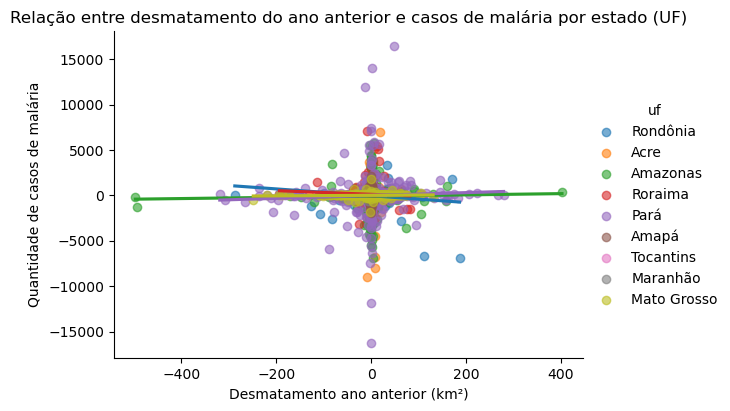

In [117]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.lmplot(
    data=df_comb,
    x="delta_desmat",
    y="delta_malaria",
    hue="uf",
    height=4,
    aspect=1.5,
    markers="o",
    ci=None, 
    scatter_kws={"alpha":0.6}
)

plt.title("Relação entre desmatamento do ano anterior e casos de malária por estado (UF)")
plt.xlabel("Desmatamento ano anterior (km²)")
plt.ylabel("Quantidade de casos de malária")
plt.show()


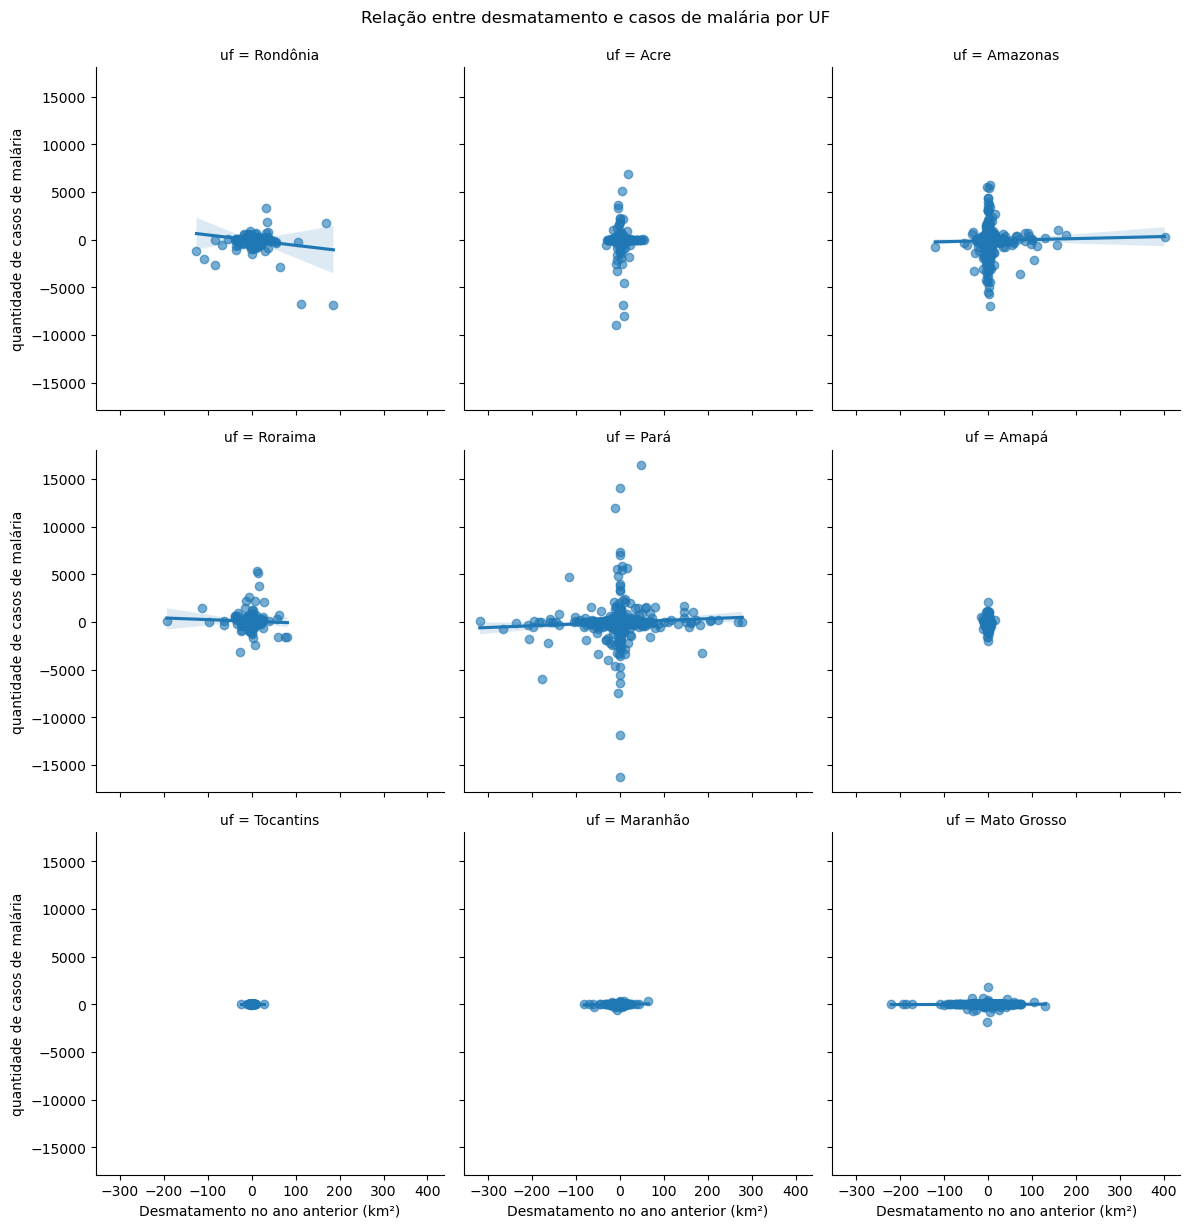

In [45]:
g = sns.lmplot(
    data=df_comb, 
    x='delta_desmat', 
    y='delta_malaria', 
    col='uf', 
    col_wrap=3,    
    height=4, 
    scatter_kws={'alpha':0.6}
)
g.set_axis_labels("Desmatamento no ano anterior (km²)", "quantidade de casos de malária")
g.fig.suptitle("Relação entre desmatamento e casos de malária por UF", y=1.02)
plt.show()